# EDA — Solar Power Production

**Target:** `SystemProduction` (Wh) — regression.
**Data:** 8,760 hourly readings, one plant, 2017.
**Questions this notebook answers:** Is the data clean? Which variables carry
signal? What does that imply for how the model must be evaluated?

In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



In [34]:
df = pd.read_csv("../Data/Solar Power Plant Data.csv")

df.head()

,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0


In [40]:
df['Date-Hour(NMT)'] = pd.to_datetime(
    df['Date-Hour(NMT)'],
    format='%d.%m.%Y-%H:%M'
)
print("Start date:", df['Date-Hour(NMT)'].min())
print("End date:", df['Date-Hour(NMT)'].max())

Start date: 2017-01-01 00:00:00
End date: 2017-12-31 23:00:00


In [35]:
df.shape

(8760, 8)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date-Hour(NMT)       8760 non-null   str    
 1   WindSpeed            8760 non-null   float64
 2   Sunshine             8760 non-null   int64  
 3   AirPressure          8760 non-null   float64
 4   Radiation            8760 non-null   float64
 5   AirTemperature       8760 non-null   float64
 6   RelativeAirHumidity  8760 non-null   int64  
 7   SystemProduction     8760 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 547.6 KB


In [38]:
df.duplicated().sum()

print("duplicate timestamps:", df['Date-Hour(NMT)'].duplicated().sum())
full = pd.date_range(df['Date-Hour(NMT)'].min(), df['Date-Hour(NMT)'].max(), freq='h')
print("missing hours:", len(full.difference(df['Date-Hour(NMT)'])))

duplicate timestamps: 0
missing hours: 8760


In [41]:
# Full-row duplicates are the wrong check here. For an hourly series what
# matters is repeated timestamps and gaps in the sequence.
print("Duplicate timestamps:", df['Date-Hour(NMT)'].duplicated().sum())

full_range = pd.date_range(df['Date-Hour(NMT)'].min(), df['Date-Hour(NMT)'].max(), freq='h')
print("Missing hours:", len(full_range.difference(df['Date-Hour(NMT)'])))
print("Rows vs 365 x 24:", len(df), 365 * 24)

Duplicate timestamps: 0
Missing hours: 0
Rows vs 365 x 24: 8760 8760


In [21]:
df['Hour'] = df['Date-Hour(NMT)'].dt.hour
hourly_production = df.groupby('Hour')['SystemProduction'].mean()

hourly_production

Hour
0        0.000000
1        0.000000
2        0.000000
3        0.000000
4        0.000000
5        0.610959
6       14.721461
7       68.952967
8      178.794520
9      422.413700
10     840.154334
11    1557.572373
12    2224.448175
13    2311.710505
14    2225.524654
15    1927.086868
16    1615.669062
17    1312.181734
18     912.964038
19     547.587675
20     207.545665
21      55.798858
22      10.166438
23       0.001712
Name: SystemProduction, dtype: float64

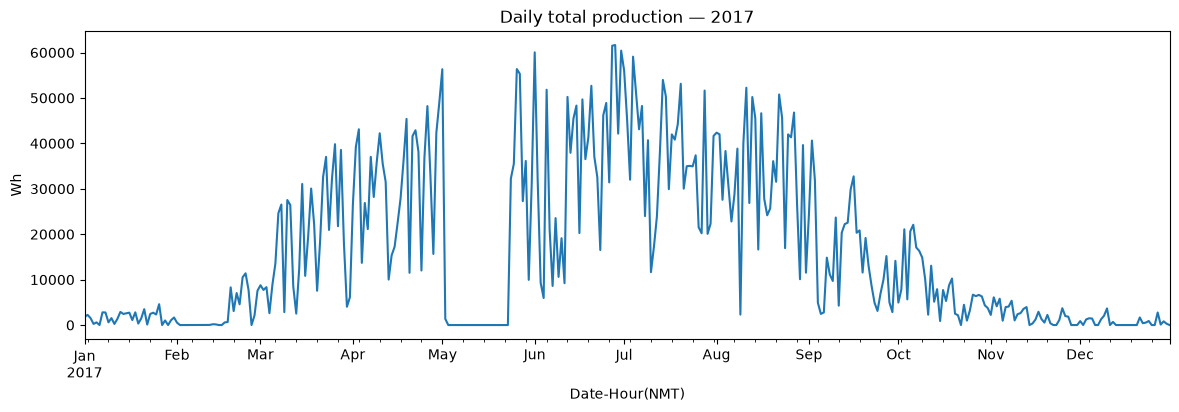

In [44]:
daily = df.set_index('Date-Hour(NMT)')['SystemProduction'].resample('D').sum()
daily.plot(figsize=(14, 4), title='Daily total production — 2017')
plt.ylabel('Wh')
plt.show()

In [45]:
df['Month'] = df['Date-Hour(NMT)'].dt.month

monthly = df.groupby('Month').agg(
    mean_production=('SystemProduction', 'mean'),
    mean_radiation=('Radiation', 'mean'),
    zero_share=('SystemProduction', lambda s: (s == 0).mean())
).round(2)
monthly

,mean_production,mean_radiation,zero_share
Month,,,
1,69.17,6.56,0.81
2,95.89,30.55,0.87
3,769.02,83.26,0.58
4,1287.20,148.03,0.45
5,459.28,187.25,0.81
6,1488.62,205.79,0.31
7,1551.70,207.10,0.32
8,1382.15,165.51,0.43
9,630.62,67.08,0.54


In [46]:
may = df[df['Month'] == 5]
may.assign(day=may['Date-Hour(NMT)'].dt.day) \
   .groupby('day')['SystemProduction'].apply(lambda s: (s == 0).mean()).round(2)

day
1     0.38
2     0.83
3     1.00
4     1.00
5     1.00
6     1.00
7     1.00
8     1.00
9     1.00
10    1.00
11    1.00
12    1.00
13    1.00
14    1.00
15    1.00
16    1.00
17    1.00
18    1.00
19    1.00
20    1.00
21    1.00
22    1.00
23    1.00
24    0.62
25    0.29
26    0.29
27    0.33
28    0.29
29    0.33
30    0.33
31    0.33
Name: SystemProduction, dtype: float64

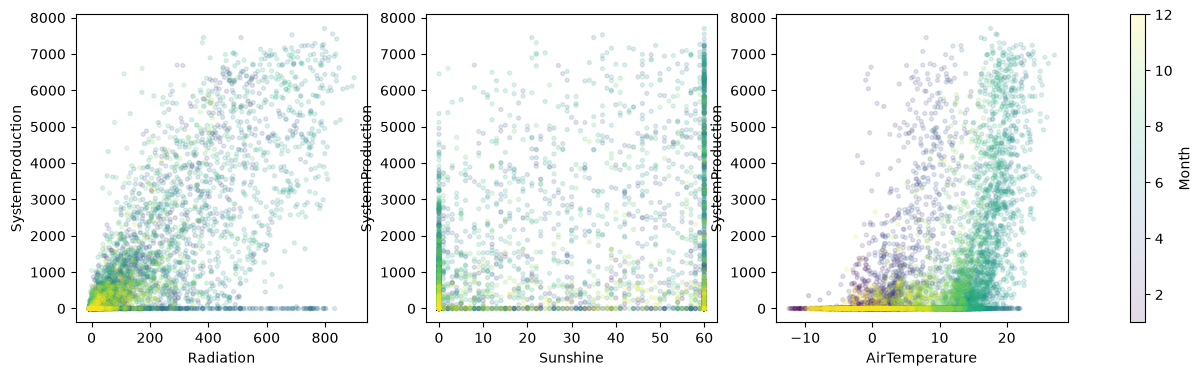

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Radiation', 'Sunshine', 'AirTemperature']):
    s = ax.scatter(df[col], df['SystemProduction'], alpha=0.15, s=8, c=df['Month'], cmap='viridis')
    ax.set_xlabel(col); ax.set_ylabel('SystemProduction')
plt.colorbar(s, ax=axes, label='Month'); plt.show()

In [27]:
correlation = df.corr(numeric_only=True)

correlation['SystemProduction'].sort_values(ascending=False)

SystemProduction       1.000000
Radiation              0.785717
Sunshine               0.564228
AirTemperature         0.480407
WindSpeed              0.195650
Hour                   0.160672
AirPressure           -0.004487
RelativeAirHumidity   -0.545252
Name: SystemProduction, dtype: float64